# Plotting Schechter function models

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## MICEcat

In [2]:
def schechter_function(M, phi_star, M_star, alpha):
    return phi_star * (10 ** (0.4 * (alpha + 1) * (M_star - M))) * np.exp(-10 ** (0.4 * (M_star - M)))

def schechter_function_redshift(M_apparent, z, phi_star, M_star, alpha):
    m = M_apparent
    H_0 = 67.7 * 10**3 #km s-1 pc-1
    M = 5 -5*np.log(z*3e5/H_0) +m
    return phi_star * (10 ** (0.4 * (alpha + 1) * (M_star - M))) * np.exp(-10 ** (0.4 * (M_star - M)))

def plot_schechter_functions(redshift, M_range, M_star, phi_star, alpha):
    
    plt.figure(figsize=(8, 6))
    plt.xlabel('Absolute Magnitude')
    plt.ylabel('Schechter Function')
    plt.title('Schuster function redshift-dependent fits')
    
    for i in range(len(redshift)):
        schechter_values = schechter_function(M_range, phi_star[i], M_star[i], alpha[i])
        plt.plot(M_range, schechter_values, label=f'z={round(redshift[i],2)}')
        
    plt.grid()
    plt.legend()
    plt.show()
    
def plot_schechter_function_with_error(redshift, M_range, M_star, M_star_err, phi_star, phi_star_err, alpha, alpha_err):
    plt.figure(figsize=(4, 3))
    plt.xlabel('Absolute Magnitude')
    plt.ylabel('Schechter Function')
    plt.title(f'Schuster function fit with errors at redshift z={round(redshift,2)}')

    schechter_values = schechter_function(M_range, phi_star, M_star, alpha)
        
    # Calculate upper and lower bounds for shaded region
    upper_bound = schechter_function(M_range, phi_star + phi_star_err, M_star + M_star_err, alpha + alpha_err)
    lower_bound = schechter_function(M_range, phi_star - phi_star_err, M_star - M_star_err, alpha - alpha_err)
        
    # Plot Schechter function curve
    plt.plot(M_range, schechter_values)
        
    # Shade the uncertainty region
    plt.fill_between(M_range, lower_bound, upper_bound, alpha=0.3)
    
    plt.grid()
    plt.show()
    
    
def schechter_function_redshift_arrays(M_apparent, redshift, M_range, M_star, phi_star, alpha):
    
    redshift_array = np.empty(len(redshift))
    schechter_array = np.empty(len(redshift))
    
    for j in range(len(redshift)):
        redshift_array[j] = redshift[j]
        schechter_array[j] = schechter_function_redshift(M_apparent, redshift[j], phi_star[j], M_star[j], alpha[j])
    
    return redshift_array, schechter_array


def plot_schechter_functions_redshift(M_apparent, redshift, M_range, M_star, phi_star, alpha):
    
    plt.figure(figsize=(8, 6))
    plt.xlabel('Redshift')
    plt.ylabel('Schechter Function')
    plt.title(f'Schechter function fits as a function of redshift')
    
    for m in M_apparent:
        redshift_array, schechter_array = schechter_function_redshift_arrays(m, redshift, M_range, M_star, phi_star, alpha)
        plt.plot(redshift_array, schechter_array, marker='o', label=f"m={round(m)}")
    
    plt.grid()
    plt.legend()
    plt.show()
    

def plot_schechter_functions_redshift_cumulative(M_apparent, redshift, M_range, M_star, phi_star, alpha):
    
    plt.figure(figsize=(8, 6))
    plt.xlabel('Redshift')
    plt.ylabel('Schechter Function')
    plt.title(f'Cumulative of Schechter function redshift-dependent fits for a range of apparent magnitude [{M_apparent.min()}, {M_apparent.max()}]')
    
    schechter_array = np.empty(len(redshift))
    
    for m in M_apparent:
        redshift_array, schechter_array_new = schechter_function_redshift_arrays(m, redshift, M_range, M_star, phi_star, alpha)
        for i in range(len(schechter_array)):
            schechter_array[i] += schechter_array_new[i]
        
    plt.plot(redshift_array, schechter_array, marker='o')
    
    plt.grid()
    plt.show()
    

In [3]:
# Define the range of absolute magnitudes
M_range = np.linspace(-25, -15, 100)

# Parameters from home/surhud.more/github/LF_function/lumfunction_abs_mag_r_schechterfitparameters.csv
fits = [[0.05,-20.43293190294056,0.043733810599470506,0.01805844768750996,0.0008596353506934979,-0.8951787908715512,0.04149036576009337],
[0.15000000000000002,-20.40954932207273,0.044075928070214425,0.01736575048014284,0.0008221126218227047,-0.8728812362038608,0.04279270339948053],
[0.25,-20.38269702511103,0.04411213425431126,0.017196790042462183,0.0008051765185677775,-0.8560937788899934,0.043641386582316775],
[0.35,-20.365771941160226,0.04370189697458498,0.017377154807799413,0.000799012890047087,-0.8447258236300911,0.04371278351247506],
[0.45,-20.343962033802665,0.04384579215139638,0.017272648093744642,0.0007895430946777352,-0.8330839966519705,0.04446023476609289],
[0.55,-20.316659008521537,0.04401683042648458,0.016944778921681,0.0007687533784343344,-0.8186276054205422,0.04543442399396748],
[0.6499999999999999,-20.292743159271364,0.043552059178195934,0.01707502842017263,0.0007577658562365034,-0.8047830911362952,0.045650219920192574],
[0.75,-20.264258516703862,0.043756909710056566,0.01669464989717592,0.0007356299470827939,-0.7915661112712187,0.046647099867842254],
[0.8500000000000001,-20.242509840513776,0.044044749004719934,0.01660403565941856,0.0007308331429365218,-0.7832643753467665,0.047565530678946574],
[0.95,-20.214532891855555,0.04434308095490004,0.016402381329443185,0.0007185719873367778,-0.7714604943551127,0.048662751226822114]]

# Extract parameters for each fit
redshift = [fit[0] for fit in fits]
M_star = [fit[1] for fit in fits]
M_star_err = [fit[2] for fit in fits]
phi_star = [fit[3] for fit in fits]
phi_star_err = [fit[4] for fit in fits]
alpha = [fit[5] for fit in fits]
alpha_err = [fit[6] for fit in fits]

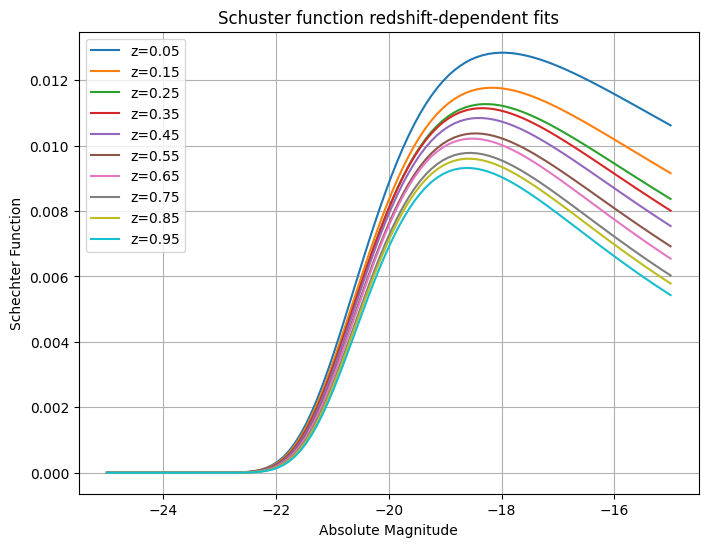

In [4]:
plot_schechter_functions(redshift, M_range, M_star, phi_star, alpha)

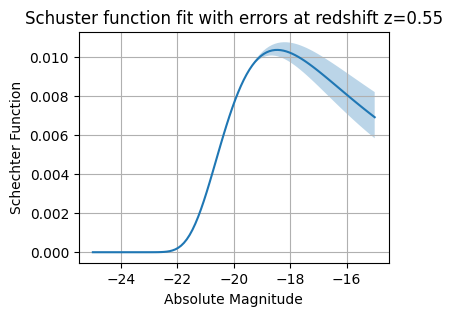

In [5]:
#for i in range(len(redshift)):
i=5
plot_schechter_function_with_error(redshift[i], M_range, M_star[i], M_star_err[i], phi_star[i], phi_star_err[i], alpha[i], alpha_err[i])

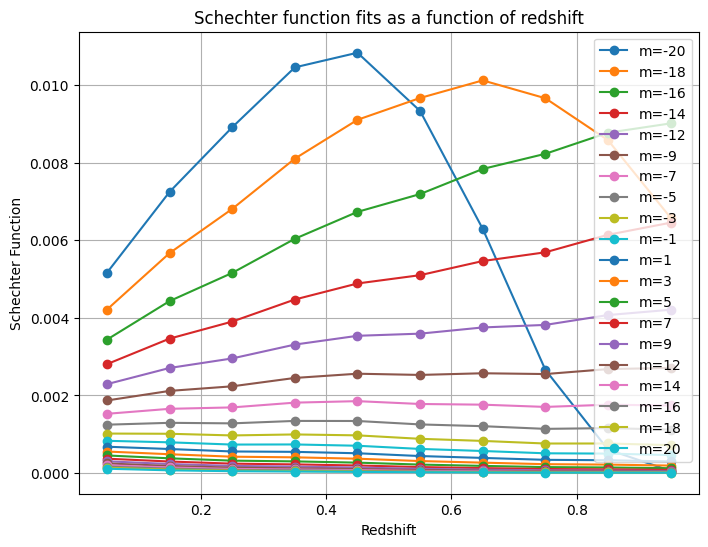

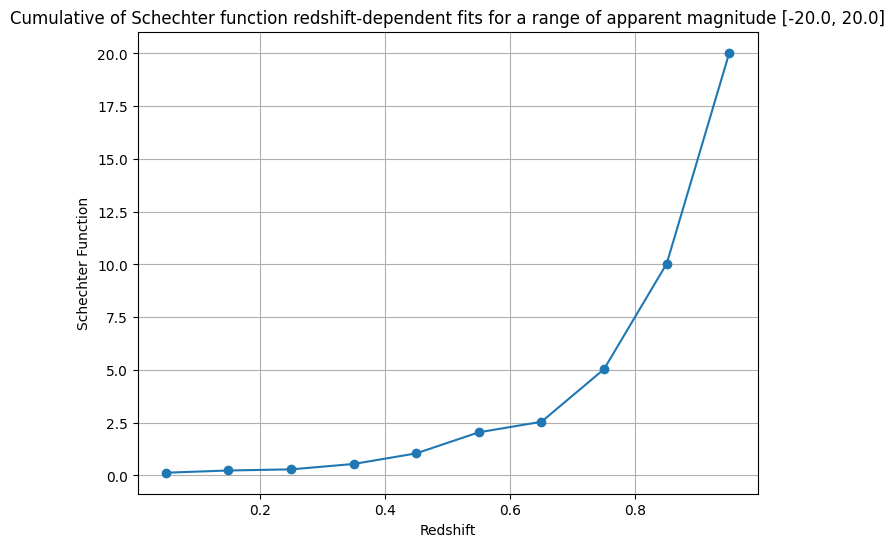

In [8]:
M_apparent = np.linspace(-20,20,20)
plot_schechter_functions_redshift(M_apparent, redshift, M_range, M_star, phi_star, alpha)
plot_schechter_functions_redshift_cumulative(M_apparent, redshift, M_range, M_star, phi_star, alpha)